# Workshop: scikit-learn

### Monday April 8 and Wednesday April 10, 2024

This week, while you are grappling with `mrjob` and getting set up on Google Cloud, we will be using our in-class time to learn a bit about <b>scikit-learn</b>.

`scikit-learn` is an open-source Python machine learning library.

It is built atop `numpy`, `scipy` and `matplotlib`, so you'll see a lot that is familiar to you already!

The idea of the library is to make a broad set of common ML/statistics models easily available, with an API that supports things like model fitting, prediction, cross-validation, etc.

## Installing `scikit-learn`

First things first, let's install `scikit-learn` (which is often abbreviated `sklearn`). The easiest way to do this, as usual, is using `pip`. Type `pip install scikit-learn` on the command line.
If you're using `conda`, then call `conda install scikit-learn`.



In [1]:
# Import numpy for making data vectors; matplotlib for plots
import matplotlib.pyplot as plt
%matplotlib inline
import numpy as np

sklearn includes a number of built-in data sets in the submodule `datasets`.

Let's have a quick look, just to get an idea: https://scikit-learn.org/stable/modules/classes.html#module-sklearn.datasets


In [2]:
from sklearn import datasets

Among the datasets included in `sklearn` is a version of the famous MNIST digits data set. We’ll see more of this when we discuss TensorFlow, so it's worth our time to take a brief look at it now.

The MNIST dataset is a collection of images of hand-written digits with accompanying labels.
The problem was originally posed by the US Postal Service when it was trying to automate mail sorting, and the data set has become a standard benchmark for image recognition, to the point that it is rather over-studied and generally too easy (I am personally guilty of using MNIST as an illustrative data set in a paper...).

In [3]:
digits = datasets.load_digits()

In [4]:
print( type(digits.data) )
digits.data.shape

<class 'numpy.ndarray'>


(1797, 64)

digits.data is a two-dimensional array, row of which are 64-dimensional vectors, which correspond to images. To display them in a way that looks reasonable, we have to reshape them to 8-by-8.

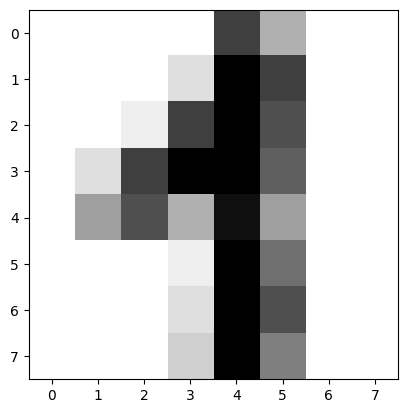

In [5]:
plt.imshow(np.reshape(digits.data[42], (8,8)), cmap='binary')
# NOTE: The cmap argument specifies a color map. See https://matplotlib.org/users/colormaps.html

Every image also comes with a label, stored in `digits.target`.

In [6]:
digits.target.shape

(1797,)

In [7]:
digits.target[42]

1

One of the main appeals of `scikit-learn` is that it supplies a wide variety of machine learning methods that work more or less "out of the box".

As an illustrative example, let's try training a support vector machine (SVM) on the MNIST digits.
See the documentation here: https://scikit-learn.org/stable/modules/generated/sklearn.svm.SVC.html#sklearn.svm.SVC

In [8]:
from sklearn import svm

In particular, since we want to train a classifier, we will create an SVC object (the C stands for "classifier").

This object requires that we specify two hyperparameters. We'll discuss these in more detail later, but for now let's just treat them as magic.

In [9]:
clf = svm.SVC(gamma=0.001, C=100.)
type(clf)

sklearn.svm._classes.SVC

Every classifier-like object in `sklearn` supports a `fit` method, which takes observations (i.e., images, in our case) and their labels and adjusts the model parameters to best fit that data.

Let's train our classifier on all of the MNIST digits except the last one, then we'll try and predict the label of the last digit.
Said another way, we're doing something akin to a single fold of leave-one-out cross-validation.

In [10]:
clf.fit(digits.data[:-1], digits.target[:-1])

SVC(C=100.0, gamma=0.001)

Every classifier object also supports a predict method, which takes an observation and tries to guess the “best” label for it, based on the model parameters.
Note that it only makes sense to call this method after we have called the `fit` method.

In [11]:
clf.predict(digits.data[-1:])

array([8])

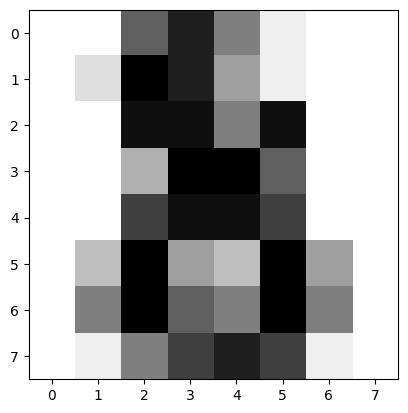

In [12]:
plt.imshow( np.reshape(digits.data[-1:],
                       (8,8)), cmap='binary')

In [13]:
digits.target[-1]

8

Looks like we got it right!

### Exercise

Repeat the above procedure (fit, predict, check the prediction) for a few different choices of the hyperparameters `gamma` and `C` in `clf = svm.SVC(gamma=0.001, C=100.)`.

In [14]:
clf = svm.SVC(gamma=0.001, C=0.0001)
clf.fit(digits.data[:-1], digits.target[:-1])
clf.predict(digits.data[-1:]),  digits.target[-1]

(array([3]), 8)

## Supervised learning example: LASSO in `sklearn`

Let's see another example of `sklearn` in action, this time implementing the LASSO.

To make sure we're all on the same page, let's start with a quick review.

### Review: linear regression and the LASSO

Recall that linear regression models a response (dependent variable) $Y_i \in \mathbb{R}$ as being explained by a collection of predictors $X_{i,1},X_{i,2},\dots,X_{i,d} \in \mathbb{R}$ weighted according to a set of coefficients $\beta_1,\beta_2,\dots,\beta_d \in \mathbb{R}$, subject to additive noise.

Succintly, in linear algebraic terms, for a set of $n$ predcitor-response pairs,
$$ Y = X \beta + \epsilon, $$
where $Y \in \mathbb{R}^n$ is a vector of $n$ responses; $X \in \mathbb{R}^{n \times d}$ has a column for each of the $d$ predictors, with each observation $X_i \in \mathbb{R}^d$ corresponding to a row; $\beta \in \mathbb{R}^d$ is a vector of coefficients, and $\epsilon \in \mathbb{R}^n$ is a vector of uncorrelated mean-zero error terms.

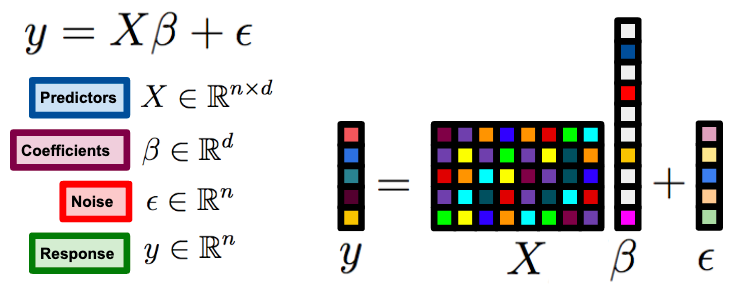

Given this data, our goal is to estimate $\beta$. The ordinary least squares (OLS) approach is to choose the value of $\beta$ that minimizes the squared errors between the responses $X \beta$ predicted by the model and the observed responses $Y$:

$$ \frac{1}{n} \sum_{i=1}^n \left( X_i^T \beta - Y_i \right)^2. $$

In many applications (e.g., audio, genomics, medical imaging), we expect only a few of the coefficients to be non-zero. That is, we expect $\beta$ to be sparse (like in the picture above, if we read white to mean zero). 

The LASSO attempts to encourage sparse solutions to the OLS problem by adding a penalty term:

$$ \frac{1}{n} \sum_{i=1}^n \left( X_i^T \beta - Y_i \right)^2 + \alpha \sum_{j=1}^d |\beta_j| . $$

This penalty term discourages non-zero coefficients. The larger $\alpha$ is, the more we are penalized for having non-zero coefficients.

Let's play around a bit with how to choose this parameter $\alpha$ (you've all probably seen model selection in at least one of your classes before, so you know more or less where we're headed with this).
We're going to generate data, varying things like the number of observations, the sparsity of $\beta$, the choice of $\alpha$, etc., and see how performance varies.

### Generating sparse linear data

First, then, we need data.
Define a function `generate_sparse_linear_data` that takes the following arguments, in order:

- `n_samp` : a positive integer specifying the total number of data points (i.e., observations)
- `dim`: a positive integer specifying the data dimension (i.e., $d$ in the notation above)
- `k` : a non-negative integer specying how many entries of the vector $\beta$ will be non-zero.
- `sigma` : a positive float, specifying the <b>standard deviation</b> of the noise terms $\epsilon$ (which we will assume to be iid mean-zero normals).
- `kappa` : a positive float, specifying the <b>standard deviation</b> of a mean-zero normal that we will use to populate non-zero entries of the coefficient vector `beta`

Your function should return a tuple of the form `(X,y,beta)` where

1. `X` is a matrix of size `n_samp` by `dim`, whose entries are generated as independent zero mean, unit variance normals
2. `y` is a vector of length `n_samp`, with `y[i]` given by the inner product of the `i`-th row of `X` with a vector of coefficients `beta`, also of length `dim`, plus noise (epsilon) generated from $N(0, \sigma^2)$.
3. `beta` is the true vector of coefficients.

Your function should choose `k` random entries of `beta` and populate them with iid draws from a normal with mean zero and standard deviation `kappa`. The remaining `dim-k` entries of `beta` should be zero. Documentation for `np.random.normal`, if you need a refresher, is here: https://numpy.org/doc/stable/reference/random/generated/numpy.random.normal.html

In [15]:
# Hint: here's an example of generating random indices
idxs = np.random.choice(10, size=5, replace=False )

In [16]:
def generate_sparse_linear_data( n_samp, dim, k, sigma, kappa ):
    # TODO: error checking. This is just demo code, so skipping.
    if k > dim:
        raise ValueError('Sparsity cannot be larger than dimension.')
    
    # Initialize beta to have all entries zero.
    beta = np.zeros( dim )
    # Pick k of the dim coefficients to be nonzero
    # and populate them with iid draws from a normal
    # with mean zero and standard deviation kappa.
    idxs = np.random.choice( dim, size=k, replace=False )
    beta[ idxs ] = np.random.normal(0, kappa, size=k)
    
    X = np.random.normal(0,1, size=(n_samp, dim))
    epsilon = np.random.normal(0, sigma, size=n_samp)
    
    y = X@beta + epsilon
    
    return (X, y, beta)

In [17]:
generate_sparse_linear_data( 10, 4, 2, 1, 1) # This should return a tuple of three arrays.

(array([[ 0.76745114, -0.91095466, -0.56933416, -1.43689252],
        [ 0.50707077, -0.35578872,  0.20177618,  0.22770153],
        [-0.65748489, -0.51575121,  1.24077372,  1.42669154],
        [ 0.74149433,  0.52240545,  0.37445303, -0.32757538],
        [-0.76320875,  1.81314587,  0.177637  ,  0.50209086],
        [-0.37254001, -0.30270722,  1.30934398, -0.28899333],
        [ 0.12506542,  0.35092932, -1.34393935,  1.78950907],
        [ 0.283455  ,  0.41953834, -0.55016345, -0.38207481],
        [-0.11368663,  1.41924944, -1.56836845, -1.15376136],
        [-0.34350248,  0.3840058 , -0.53988762,  1.98222244]]),
 array([ 3.24707573, -2.55995407, -2.85717805, -1.40693105,  1.56505201,
         0.42985836, -0.81693896, -1.8107732 ,  2.16426249, -0.09506561]),
 array([ 0.        ,  0.39657946,  0.        , -0.76687614]))

Once we've generated data, we need to split it into a train set (i.e., data that we fit the model on) and a test set (i.e., the data that our model hasn't seen during training that lets us estimate its performance).
I assume you have seen the notion of train/test splitting before in your classes, but if not: https://en.wikipedia.org/wiki/Training,_validation,_and_test_data_sets

Write a function called `train_test_split` that takes a numpy array `X` (which will represent a matrix of observations, one per row), a numpy array `y` (representing a vector of responses) and a float `train_portion` between `0.0` and `1.0` (inclusive) and returns a four-tuple `(Xtrain,ytrain,Xtest,ytest)` corresponding to splitting the data `(X,y)` into a train set of `train_portion * n` elements (where `n` is the number of rows of `X`; handling rounding as you wish).
Thus, `Xtrain` and `Xtest` should have the same number of columns, and their numbers of rows should add to the number of rows of `X`; `ytrain` and `ytest` should similarly have their lengths add to the length of `y`, and the `i`-th entry of `ytrain` or `ytest` should correspond to the response of the `i`-th row of `Xtrain` or `Xtest`, respectively.

In [18]:
import math # Hint: you might find the math.ceil function useful here for rounding.
math.ceil(3.4)

4

In [19]:
# Hint: you may find the numpy setdiff1d function useful.
# Pick a random set of indices to be in the training set, then use this
# function to take their complement!
# See https://numpy.org/doc/stable/reference/generated/numpy.setdiff1d.html for details.
np.setdiff1d( np.arange(5), [1,2,3])

array([0, 4])

In [20]:
def train_test_split( X, y, train_portion ):
    
    # Figure out the size of the train set.
    n = X.shape[0] # X is n-by-dim
    ntrain = math.ceil( train_portion*n )
    
    # Pick out the training indices and get the corresponding rows.
    train_idxs = np.random.choice( n, size=ntrain, replace=False )
    Xtrain = X[ train_idxs, :]
    ytrain = y[ train_idxs ]
    
    # Then need to get Xtest and ytest. Use np.setdiff1d from above.
    test_idxs = np.setdiff1d( np.arange(n), train_idxs )
    Xtest = X[ test_idxs, :]
    ytest = y[ test_idxs ]
    
    return (Xtrain, ytrain, Xtest, ytest)

In [21]:
### Here is some test code that should run without error once the above is correct.
### The resulting train and test sets should be approximately the same size, since p=0.5
(X,y,beta) = generate_sparse_linear_data( 10, 3, 2, 1, 1 )
train_test_split( X, y, 0.5 )

(array([[-0.75738014, -1.18823285, -0.77869363],
        [ 0.69446309,  1.79451637,  0.13234181],
        [ 1.16848949, -1.51889402, -0.6825799 ],
        [ 0.8099568 , -1.11843118,  0.7061934 ],
        [ 0.2137017 ,  0.58983925, -3.48506539]]),
 array([0.87256437, 0.65891843, 0.6518219 , 2.46610227, 0.29251445]),
 array([[ 0.45247021,  0.77131505, -0.20680873],
        [ 0.73901153, -0.41608628, -0.47743712],
        [-1.338267  , -0.34224325, -1.33925033],
        [ 0.32760414,  1.37299634,  0.98498985],
        [ 0.0582419 ,  0.08459803,  0.20462593]]),
 array([-0.66097782, -0.18346218,  0.73087336,  0.73056852,  0.9742126 ]))

Okay, now it's time to actually fit a model to the data.
Remember that every model-like object in numpy has a `fit` method for fitting the model to data.
The recipe is always

1. Initialize a model object of the appropriate type
2. Fit the model to data (usually observations and responses/labels; but we'll see an unsupervised learning example below where we only have observations)
3. Make predictions on previously unseen data, evaluate the accuracy of those predictions, etc.

Here's the documentation for the LASSO: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html)

<b>Question:</b> recall that the SVC (SVM classifier) took two mandatory (hyper)parameters. How many does the LASSO need in `sklearn`?

<b>Answer:</b> the $\alpha$ parameter (called `alpha` in `sklearn`).

Write a function `fit_lasso` that takes three arguments: observations `X`, responses `y` and a non-negative float `alpha`, and returns an `sklearn` Lasso object that corresponds to the LASSO fit to the data `(X,y)` with $\alpha$ parameter `alpha`.

In [22]:
import sklearn.linear_model as sklm

In [23]:
def fit_lasso( X, y, alpha ):
    lasso = sklm.Lasso( alpha=alpha )
    lasso.fit( X, y )
    return lasso

In [24]:
### Here's some test code you can try.
(X,y,beta) = generate_sparse_linear_data( 10000, 10, 3, 1, 1 )
(Xtrain,ytrain,Xtest,ytest) = train_test_split( X, y, 0.8 )
lasso = fit_lasso( Xtrain, ytrain, 1.0 )

In [25]:
### The fitted coefficients are stored in the coef_ attribute.
### Uncomment to verify that your code worked and that lasso is indeed a fitted model.
lasso.coef_

array([-0.        ,  0.        ,  0.        , -0.        ,  0.        ,
        0.        , -0.31172863, -0.        , -0.19386438,  0.        ])

In [26]:
# Compare to our true beta
beta

array([ 0.        ,  0.        ,  0.        ,  0.        ,  0.        ,
        0.        , -1.30706162, -0.74999709, -1.20766762,  0.        ])

Okay, last step! Having estimated $\beta$ from that data, how do we assess how well we did?

Well, in this situation, we know the true value of $\beta$ (after all, we picked it ourselves!), but we are usually not so lucky.
This is where the test set comes in.
Having fit a model, we can make predictions on new data using the `predict` method, which is supported by all model-like objects in `sklearn`: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html#sklearn.linear_model.Lasso.predict

The simplest way to measure our success is to check how well our predicted responses on the test set match the true responses (in the test set! Measuring our success on the train set is cheating!).
The best (or at least most obvious) way to do that is using $R^2$.

In `sklearn`, this is available in the `metrics` submodule, which has a whole mess of different functions for measuring the quality of classifiers, predictors, etc: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html

Write a function `evaluate_r2` that takes three arguments:

1. An `sklearn` `Lasso` object that supports the `predict` method.
2. A data matrix `Xtest` (as a `numpy` array) representing the independent variables in the test set
3. A a `numpy` array `ytest` representing a vector of the dependent variables in the test set

Your function should return the $R^2$ score between the true responses in `ytest` and the responses predicted by the given LASSO model.

In [27]:
import sklearn.metrics

def evaluate_r2( lasso, Xtest, ytest ):
    ypred = Xtest @ lasso.coef_
    return sklearn.metrics.r2_score(ytest, ypred)

In [28]:
### Uncomment this to test; resulting r2 should be reasonably high.
evaluate_r2( lasso, Xtest, ytest )

0.24707425362250057

Of course, this is hardly the only way we could evaluate the quality of our model.

For example, a different but equally important measure of performance is how well we recovered the non-zero entries of $\beta$ (i.e., recovery of the <i>support</i>).

For example, consider:

In [29]:
# (imagined) indices of non-zero entries of "beta-hat":
nonzero_coefs_estimated = np.array([ 24, 144, 198, 274, 283, 334, 491])

In [30]:
# (imagined) indices of non-zero entries of "beta-hat":
nonzero_coefs_true = np.array([24, 144, 198, 213, 244, 274, 283, 288, 334, 491])

In this (imaginary) example, we have committed both type-I and type-II errors, in the sense that there are purported non-zero coefficients that are zero in the true $\beta$, and there are true non-zero coefficients that we have failed to identify.

A natural way to measure success in these kinds of problems is to use the F1 score. It is a harmonic mean between the recall and precision.
https://scikit-learn.org/stable/modules/generated/sklearn.metrics.f1_score.html

Write a function `evaluate_f1` that takes two arguments:

1. `lasso`, an `sklearn` LASSO object that has been fit to data.
2. `betatrue`, a `numpy` array representing the true model coefficients

And returns the F1 score of the given `lasso` model with respect to the true vector of coefficients `beta`.

<b>Note:</b> since we try to avoid making equality comparisons between floats, you should choose a threshold (e.g., $10^{-8}$) such that entries smaller than this amount are considered as "equal" to zero (i.e., they do not count as nonzero coefficients).

In [31]:
def evaluate_f1( lasso, betatrue ):
    thresh=1e-8 # Threshold for determining "not zero"
    
    # First, figure out the indices of the non-zero entries
    # in the true beta and its estimate.
    true_idxs = np.greater( np.abs(betatrue), thresh )
    estd_coefs = lasso.coef_
    estd_idxs = np.greater( np.abs(betatrue), thresh )
    
    # Recall is the fraction of true indices that we correctly
    # guess. It would be natural to write a helper function for
    # this, but let's just write it out here.
    # We will get the set of indices that are in both true_idxs
    # and estd_idxs, count them up, and figure out what fraction
    # of the total set of true indices that corresponds to.
    
    # For completeness, let's handle the edge case where
    # true_idxs is empty.
    # In that case, we will take the recall to be (trivially) 1:
    # we correctly retrieved all of the true elements,
    # because there are none!
    recall = 1.0
    if len( true_idxs ) > 0:
        intersection = np.intersect1d( true_idxs, estd_idxs )
        recall = len( intersection )/len( true_idxs )
    
    # Now, the precision is the fraction of our estimated
    # support indices that are "true positives".
    precision = 1.0 # Again, to handle the empty set edge case
    if len( estd_idxs ) > 0:
        precision = len( intersection )/len( estd_idxs )
    
    # Now, to compute the F1 score, we take the harmonic mean.
    # https://en.wikipedia.org/wiki/Harmonic_mean
    return 2/(1/precision + 1/recall)
    

In [32]:
### This code should run without error once you've written the above
evaluate_f1( lasso, beta )

0.2

Now, with all that set up, we are finally ready to answer our original question.

<b>Bonus exercise:</b> choose one or more of the parameters in our setup (e.g., the number of observations, the sparsity `k`, the standard deviations) and use the above functions to explore how model performance (as measured by either of the measure above) varies with that parameter (or parameters).

Choose an appropriate way to visualize this change in performance (e.g., a line plot, a heat map, etc), and implement it using `matplotlib`.

## Unsupervised learning example: the Iris data, yet again

Like all good machine learning libraries, `sklearn` includes the famed Iris dataset among its built-ins.
Let's have a look.

Text(0, 0.5, 'petal ratio')

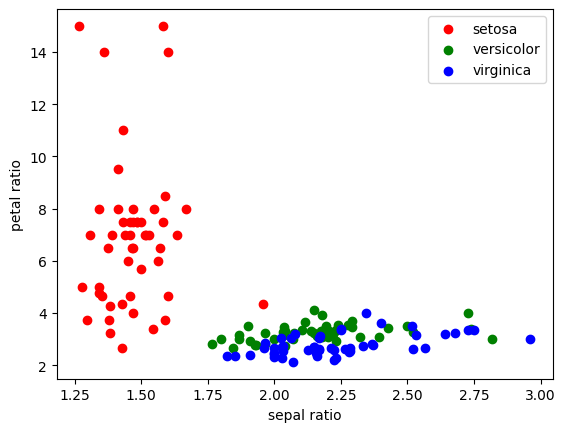

In [33]:
iris = datasets.load_iris()
X = iris.data
y = iris.target

# Let's use our old friends the petal and sepal ratios, just so we have nice two-dimensional data to work with.
sepal_ratio = X[:,0]/X[:,1]
petal_ratio = X[:,2]/X[:,3]

# Three colors to assign (rather arbitrarily) to our three species:
colors=['red','green','blue']
for i in np.unique(y): #np.unique[y] is [0,1,2]
    plt.scatter(sepal_ratio[y==i], petal_ratio[y==i],
                c=colors[i])

plt.legend(('setosa', 'versicolor', 'virginica'))
plt.xlabel('sepal ratio')
plt.ylabel('petal ratio')

Just looking at that plot, it's clear that there’s a cluster structure in the data.
How can we discover it without using the label information?

A natural choice is to use a $k$-GMM (Gaussian Mixture Model).
The basic idea is to model the data as being generated by a mixture of Gaussians, in which each Gaussian generates one cluster.

For each cluster, we'll have to estimate a (multivariate) mean and covariance, and we'll have to figure out which observations belong to which clusters.

This latter part of the problem is actually computationally very hard, but we can find a good approximate solution using the expectation-maximization algorithm (EM; https://en.wikipedia.org/wiki/Expectation-maximization_algorithm)

For example, after fitting covariances, we might hope to see something like this picture (the ellipses describe the level sets of the three Gaussians):

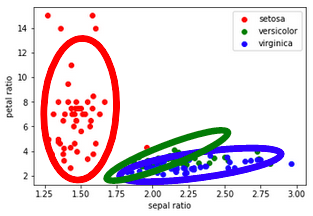

The `sklearn` implementation of k-GMM is documented here: https://scikit-learn.org/0.16/modules/generated/sklearn.mixture.GMM.html

Let's have a quick read to make sure we understand what is going on...

...so, like the models above, we initialize a `GaussianMixture` model by specifying its parameters, then we apply it to data.

Just for illustration's sake, let's try initializing this with the "wrong" number of clusters.

<b>Aside question:</b> why did I put "wrong" in quotes, there?

In [34]:
from sklearn import mixture

gmm = mixture.GaussianMixture(n_components=2, n_init=10,
                              covariance_type='full')

Now, we need to fit our model to data. Again, we use the `fit` method.
In this case, fitting consists of estimating the means and covariances of the 2 components.

In [35]:
# GMM expects our data in a matrix, one observation per row.
# stack takes our two data vectors and makes them into a single matrix, one per column.
R = np.stack([sepal_ratio,petal_ratio], axis=1)

gmm.fit(R)

GaussianMixture(n_components=2, n_init=10)

...and we can plot our data again, this time coloring it according to the estimated labels (here we use the `predict` method again):

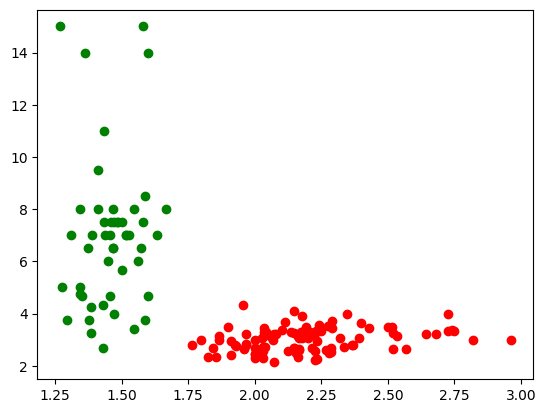

In [36]:
labs = gmm.predict(R)
for i in np.unique(labs):
    plt.scatter(sepal_ratio[labs==i], petal_ratio[labs==i],
                c=colors[i])

We can already see a hard problem here. In this case, we happen to know that there are really three classes here (there are three species in the data), but typically, we don’t know the classes ahead of time, so we don’t know how to choose `n_components`. This is called <b>model selection</b>. More on this soon.

What if we set `n_components` to the "correct" number?

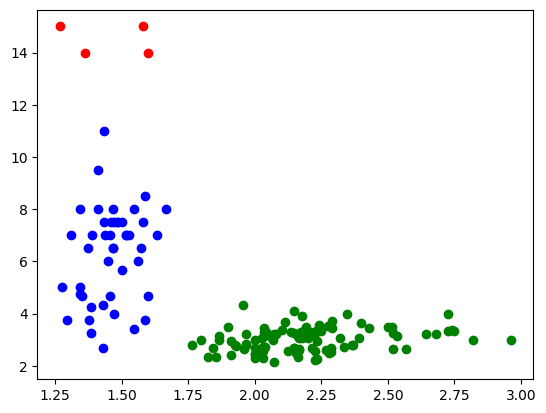

In [37]:
# Initialize again, this time with n_components=3, fit, etc.
gmm = mixture.GaussianMixture(n_components=3, n_init=10,
                              covariance_type='full')
gmm.fit(R)
labs = gmm.predict(R)
for i in np.unique(labs):
    plt.scatter(sepal_ratio[labs==i], petal_ratio[labs==i],
                c=colors[i])

It looks like even if we choose the correct number of components, the “ratio” representation of the data collapses the versicolor and virginica species, and we get a weird solution.

In the code block below, perform the same 3-component GMM clustering, but this time applied to the full four-column Iris data.
Plot the data colored according to the estimated species labels and compare to the true labels we plotted above.

In [38]:
# TODO: code goes here.

### Model selection: how many components should we use?

How should we choose the number of clusters in practice? Typically we don’t know, e.g., that there are three species in the data.
One popular solution is to use an <b>information criterion</b>, which measures how well a model reflects the data, while penalizing model complexity.

That is, if we want to use a model with more parameters, those parameters had better pay rent!

<b>Examples:</b>

- https://en.wikipedia.org/wiki/Bayesian_information_criterion
- https://en.wikipedia.org/wiki/Akaike_information_criterion
- https://en.wikipedia.org/wiki/Mallows%27s_Cp

See also https://en.wikipedia.org/wiki/Minimum_description_length

Let's try this, then:
We'll consider a range of different choices for the number of components, as well as several different ways of estimating the covariances.
For each combination, we'll fit a GMM and assess its fit according to the Bayesian information criterion (BIC).

<b>Note:</b> smaller BIC is better!

In [39]:
# Setup. Load the data, set a range of numbers of clusters, covariance estimation techniques, etc.
iris = datasets.load_iris()
X = iris.data
y = iris.target
n_components_range = range(1, 7)
covar_types = ['spherical', 'tied', 'diag', 'full']
# Allocate a matrix of zeros in which we will store BIC for each of our models.
bics = np.zeros(shape=(len(covar_types),len(n_components_range)))

In [40]:
# Now iteratre through all combinations of covariance and n_components, and assess BIC for each one.
for i in range(len(covar_types)):
    cvtype = covar_types[i]
    for j in range(len(n_components_range)):
        n_comps = n_components_range[j]
        # Fit a Gaussian mixture with EM
        gmm = mixture.GaussianMixture(n_components=n_comps,
                                      covariance_type=cvtype)
        gmm.fit(X)
        bics[i,j] = gmm.bic(X)

And now, let's visualize the data.

Make a barplot to show, for each of the covariance estimation techniques, how BIC varies with the number of components.

So you'll have six different x-axis ticks, and within each ticks, you'll want to create four bars side by side, corresponding to our four different covariance estimation methods.

<b>Important note:</b> in your call to `plt.bar` to make a bar plot, you'll want to supply a set of x-values that look like `inds+i*barwidth`, where `i` runs over the numbers of bars (four, corresponding to our four different fitting methods), and `barwidth=0.2`.
You'll also need to supply the optional keyword argument `width=barwidth` and do a bit of tinkering with other arguments to things like `plt.xticks` to make this look "right". Don't get too hung up on it during class-- but it's worth taking some time to get it just right outside of class to get some practice with the more obscure corners of `matplotlib`.

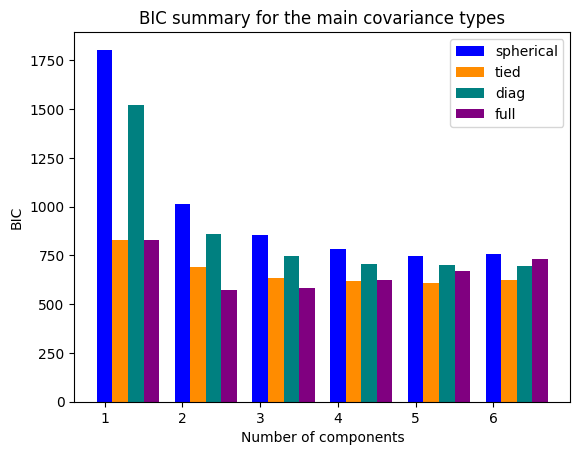

In [41]:
barwidth=0.2
inds = np.array(list(n_components_range))
colors = ['blue', 'darkorange', 'teal', 'purple']
for i in range(len(colors)):
    plt.bar(inds+i*barwidth, bics[i,:], color=colors[i],
    width=barwidth, label=covar_types[i]) # This is the barwidth thing we mentioned above.
    plt.title('BIC summary for the main covariance types')
    plt.xlabel('Number of components')
    plt.ylabel('BIC')
    _ = plt.legend()

Spherical and diagonal covariance both seem to think that more components is always better (at least up to 6, anyway). This is unsurprising given the data: it’s simple to check that the dimensions of the iris data are correlated, so spherical or diagonal covariances will do poorly: they assume that all correlations across dimensions are zero.

Full covariance has its lowest BIC at 2, while tied covariance selects (the correct) number of components to be 3.

The lesson here (and it is an important one to bear in mind when we are working with real data!) is not that one of these methods will always be best, but that even a principled technique like BIC may sometimes give us the wrong answer.

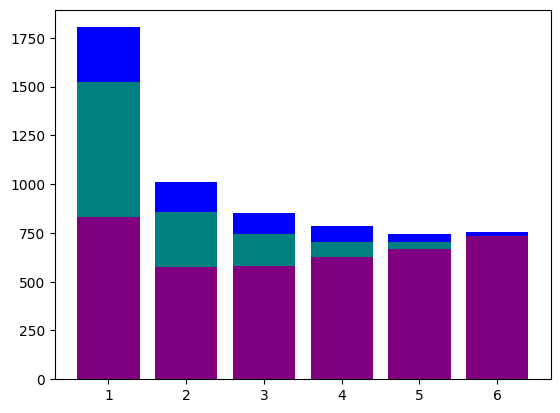

In [42]:
# Aside: This code demonstrates why you need the barwidth business in the previous code block.
# The code in this block makes the incorrect bar graph. 
inds = np.array(list(n_components_range))
colors = ['blue', 'darkorange', 'teal', 'purple']

for i in range(len(colors)):
    plt.bar(inds, bics[i,:], color=colors[i], label=covar_types[i])

### Cross-validation in sklearn

`sklearn` includes tools for cross-validation (CV). Recall that CV is how we choose parameters like $\alpha$ in the LASSO.

The basic idea is to try many different choices of parameter and keep the one that gives the best performance on the training data.

There are many ways to do this, but we’ll focus on K-fold CV. See https://en.wikipedia.org/wiki/Cross-validation_(statistics) for more.

Once again, I am mostly assuming that you've seen this at least once before, so we are glossing over some details, but the basic framework is:

1. Split the training data into K “folds” (K=5 in the example below)
2. For each fold, we train on the other K-1 folds and evaluate the trained model on the “held-out” fold.

On each fold, we evaluate all of the models that are under consideration. We then average each model over the folds and keep the model with the best average score.

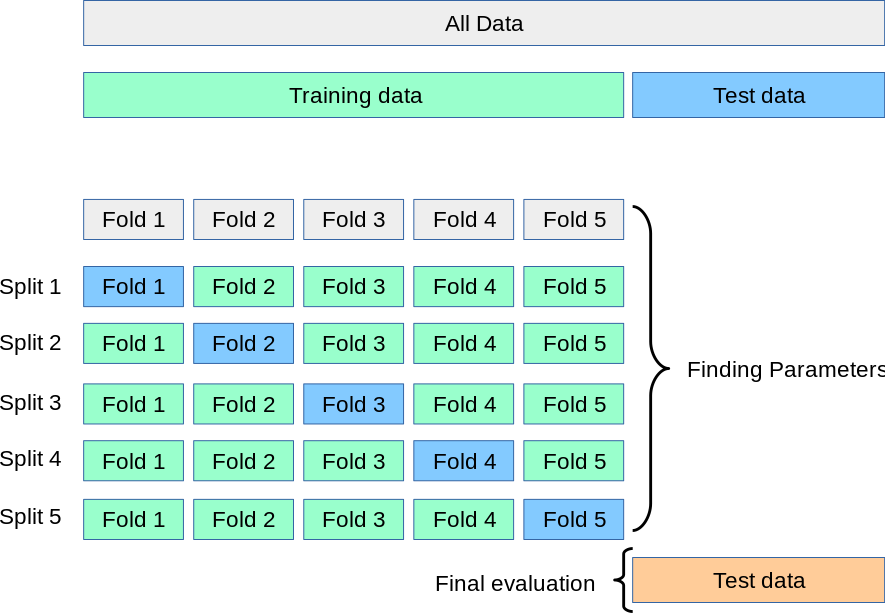

Image credit: https://scikit-learn.org/stable/modules/cross_validation.html

First, let's generate some sparse data, just like before.
We could use our function from above, but I'm including this so that the notebook runs even if you haven't defined that function, yet.

In [43]:
from sklearn.model_selection import cross_val_score
(n_samp, dim, k) = (200, 500, 10)
beta = np.zeros(dim)
inds = np.random.choice(np.arange(dim), size=k, replace=False)
beta[inds] = 5*np.random.randn(k)
X = np.random.randn(n_samp, dim)
y = np.dot(X, beta) + 0.1*np.random.randn(n_samp)

In [44]:
# Now, CV is straight-forward. The cross_val_score function takes a model and does (randomized) CV on it,
# with the number of folds specified by the cv keyword.

from sklearn import linear_model
lasso = linear_model.Lasso(alpha=5)
scores = cross_val_score(lasso, X, y, cv=10)
scores

array([0.77748345, 0.67957392, 0.67027635, 0.71688377, 0.61741272,
       0.64687417, 0.64936227, 0.62832657, 0.65522527, 0.66729571])

...wait, one thing that seems missing-- we never told `sklearn` what "score" to use... Well, this is one of those annoying things, where `sklearn` has a favorite default for every model. For the LASSO it's $R^2$.

See https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.cross_val_score.html#sklearn.model_selection.cross_val_score for details

Now, what we want is to apply CV for a bunch of different models (in our case, this corresponds to different choices of $\alpha$), and then compare them.

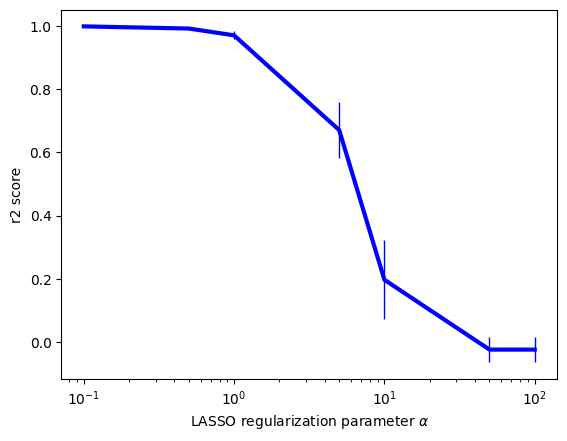

In [45]:
alphavals = np.array([0.1, 0.5, 1.0, 5, 10.0, 50, 100])
mean_scores = np.zeros(alphavals.shape) # Store means and SDs for the different CV scores.
sd_scores = np.zeros(alphavals.shape)

for i in range(len(alphavals)):
    lasso = linear_model.Lasso(alpha=alphavals[i])
    scores = cross_val_score(lasso, X, y, cv=10)
    mean_scores[i] = np.mean(scores)
    sd_scores[i] = np.std(scores)

plt.errorbar(alphavals, mean_scores, yerr=2*sd_scores,
             color='blue', linewidth=3, elinewidth=1)
plt.xscale('log'); plt.ylabel('r2 score')
_=plt.xlabel(r'LASSO regularization parameter $\alpha$')